In [38]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [39]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [40]:
class Model(nn.Module): #classmodel that inherits the module nn
  #4 features of flower
  #-->> hidden layer h1
  #--> hidden layer h2
  #-->output 3 classes of output flowers
  def __init__(self,in_features=4,h1=8,h2=9,out_features=3):
    super().__init__()
    self.fc1 = nn.Linear(in_features,h1)
    self.fc2 = nn.Linear(h1,h2)
    self.out = nn.Linear(h2,out_features)
  def forward(self,x):
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.out(x)
    return x

In [41]:
torch.manual_seed(67) #randomseed
model = Model()

In [42]:
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

url = 'https://gist.githubusercontent.com/netj/8836201/raw/6f9306ad21398ea43cba4f7d537619d0e07d5ae3/iris.csv'
my_df = pd.read_csv(url)

In [43]:
my_df.head()

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [44]:
#last column string to int
my_df['variety'] = my_df['variety'].replace('Setosa',0)
my_df['variety'] = my_df['variety'].replace('Versicolor',1)
my_df['variety'] = my_df['variety'].replace('Virginica',2)

/tmp/ipython-input-778216500.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  my_df['variety'] = my_df['variety'].replace('Virginica',2)


In [45]:
#trainsplit
X = my_df.drop('variety',axis=1)
y = my_df['variety']

#numpy array
X = X.values
y = y.values

from sklearn.model_selection import train_test_split

#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=0.2, random_state=41)
my_df


,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [46]:
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

In [47]:
#64int = longtensor
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [48]:
#set criterion to measure error
criterion = nn.CrossEntropyLoss()
#Optimizer, learning rate (if no learning after few iterations (epochs))
optimizer = torch.optim.Adam(model.parameters(),lr=0.01)


In [49]:
#epochs
epochs = 100
losses =[]

for i in range(epochs):
    y_pred = model(X_train)# forward
    loss = criterion(y_pred, y_train)# loss

    optimizer.zero_grad()# zero grads
    loss.backward()# backprop
    optimizer.step()# update weights

    losses.append(loss.item())

    if i % 10 == 0:
        print(f"Epoch: {i}, Loss: {loss.item():3f}")

Epoch: 0, Loss: 1.081123
Epoch: 10, Loss: 0.941986
Epoch: 20, Loss: 0.762925
Epoch: 30, Loss: 0.538486
Epoch: 40, Loss: 0.371385
Epoch: 50, Loss: 0.257037
Epoch: 60, Loss: 0.155608
Epoch: 70, Loss: 0.087001
Epoch: 80, Loss: 0.051509
Epoch: 90, Loss: 0.033251


Text(0.5, 0, 'epochs')

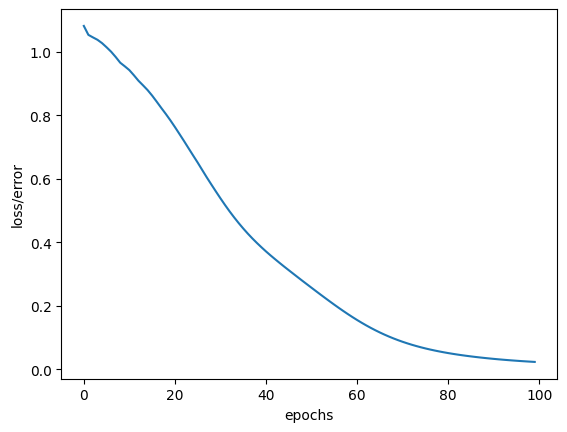

In [50]:
plt.plot(range(epochs),losses)
plt.ylabel("loss/error")
plt.xlabel("epochs")

In [51]:
with torch.no_grad(): #turn of back prop
    y_eval = model.forward(X_test) #X_test features from our test.
    loss = criterion(y_eval,y_test) #find the loss

In [52]:
loss

tensor(0.0796)

In [56]:
correct = 0
with torch.no_grad():
    for i, data in enumerate(X_test):
      y_val = model.forward(data)

      print(f'{i+1}.){str(y_val)} \t {y_test[i]} \t {y_val.argmax().item()}')

      if y_val.argmax().item() == y_test[i]:
        correct +=1
print(f'we got {correct} correct')

1.)tensor([-2.7878,  2.9128,  6.7243]) 	 2 	 2
2.)tensor([-3.7237,  2.5343,  9.6610]) 	 2 	 2
3.)tensor([-4.0384,  2.9632, 10.4241]) 	 2 	 2
4.)tensor([-1.2326,  4.8556,  1.3146]) 	 1 	 1
5.)tensor([-3.2469,  3.2655,  7.9478]) 	 2 	 2
6.)tensor([-0.2735,  5.1173, -1.1549]) 	 1 	 1
7.)tensor([-2.4850,  3.5597,  5.5627]) 	 2 	 2
8.)tensor([-1.0175,  5.2006,  0.5355]) 	 1 	 1
9.)tensor([-2.8008,  3.5309,  6.5137]) 	 2 	 2
10.)tensor([-3.8669,  2.8155,  9.9735]) 	 2 	 2
11.)tensor([-2.2361,  3.8805,  4.6929]) 	 2 	 2
12.)tensor([  8.6631,   3.1048, -16.0206]) 	 0 	 0
13.)tensor([  7.8135,   2.8390, -14.5231]) 	 0 	 0
14.)tensor([ 0.6016,  4.3157, -2.5992]) 	 1 	 1
15.)tensor([  8.4852,   3.0717, -15.7076]) 	 0 	 0
16.)tensor([-2.1863,  3.9763,  4.5061]) 	 2 	 2
17.)tensor([  8.2081,   2.9672, -15.2188]) 	 0 	 0
18.)tensor([-2.5447,  3.4297,  5.7926]) 	 1 	 2
19.)tensor([  8.7224,   3.1176, -16.1250]) 	 0 	 0
20.)tensor([  7.2467,   2.6635, -13.5242]) 	 0 	 0
21.)tensor([ 0.1410,  4.6371, -

In [59]:
new_iris = torch.tensor([4.7, 3.2, 1.3, 0.2], dtype=torch.float32)

with torch.no_grad():
    print(model(new_iris))

tensor([  8.1932,   2.9554, -15.1924])


In [60]:
newer_iris = torch.tensor([5.9, 1.0, 5.3, 1.0], dtype=torch.float32)

with torch.no_grad():
  print(model(newer_iris))

tensor([-3.7198,  1.4127, 10.1018])


In [70]:
# Save
torch.save(model.state_dict(), 'iris_model.pt')

# Load
new_model = Model()
new_model.load_state_dict(torch.load('iris_model.pt'))
new_model.eval()

Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)